In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

import pickle
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [42]:
df = pd.read_csv("corrupt_data.csv")

df.head()

,project_id,state,city,year,project_category,road_length_km,road_lanes,road_type,bridge_length_m,bridge_type,...,material_cost_rs,labour_cost_rs,equipment_cost_rs,expected_cost_rs,allocated_budget_rs,actual_cost_rs,corruption_amount_rs,corruption_risk_score,population,traffic_density
0,1,Tamil Nadu,Chennai,2020,Road,16.73,2,Highway,1768.58,Railway Overbridge,...,77930463,29977359,4057545,111965367,176036291,112476032,63560259,0.361,13515808,64
1,2,Tamil Nadu,Chennai,2020,Road,5.16,6,Highway,1465.14,Railway Overbridge,...,20388475,30026979,1532448,51947902,64264913,54181184,10083729,0.157,10892170,82
2,3,Tamil Nadu,Chennai,2020,Road,34.77,4,Highway,602.03,Flyover,...,60237411,15894170,3979226,80110807,113546879,77320104,36226775,0.319,426964,56
3,4,Tamil Nadu,Chennai,2020,Road,37.60,2,City Road,1173.41,Railway Overbridge,...,58143135,30177970,8828799,97149904,147744722,97391251,50353471,0.341,1043697,53
4,5,Tamil Nadu,Chennai,2020,Road,3.77,2,Highway,1899.13,Flyover,...,59122967,6573988,9070717,74767672,93164529,69503634,23660895,0.254,13237522,20


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89600 entries, 0 to 89599
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   project_id             89600 non-null  int64  
 1   state                  89600 non-null  object 
 2   city                   89600 non-null  object 
 3   year                   89600 non-null  int64  
 4   project_category       89600 non-null  object 
 5   road_length_km         89600 non-null  float64
 6   road_lanes             89600 non-null  int64  
 7   road_type              89600 non-null  object 
 8   bridge_length_m        89600 non-null  float64
 9   bridge_type            89600 non-null  object 
 10  building_area_sqft     89600 non-null  float64
 11  floors                 89600 non-null  int64  
 12  building_type          89600 non-null  object 
 13  park_area_acres        89600 non-null  float64
 14  park_facilities        89600 non-null  object 
 15  ma

In [44]:
df.isnull().sum()

project_id               0
state                    0
city                     0
year                     0
project_category         0
road_length_km           0
road_lanes               0
road_type                0
bridge_length_m          0
bridge_type              0
building_area_sqft       0
floors                   0
building_type            0
park_area_acres          0
park_facilities          0
material_cost_rs         0
labour_cost_rs           0
equipment_cost_rs        0
expected_cost_rs         0
allocated_budget_rs      0
actual_cost_rs           0
corruption_amount_rs     0
corruption_risk_score    0
population               0
traffic_density          0
dtype: int64

In [45]:
df.fillna(0, inplace=True)

#### Corruption by State 

/var/folders/t9/h05j4qf9681bhyc90g6gvsw80000gn/T/ipykernel_20210/2704145585.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


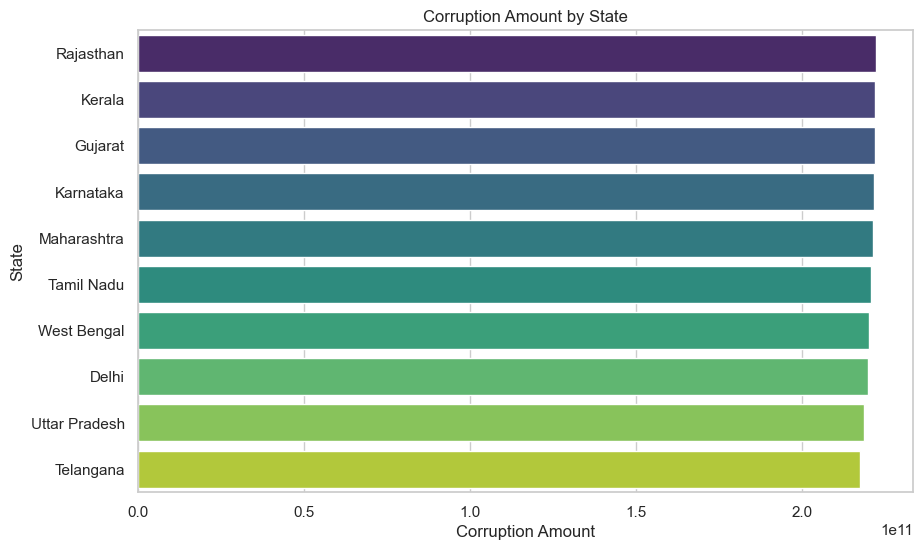

In [46]:
state_corr = df.groupby("state")["corruption_amount_rs"].sum().sort_values(ascending=False)

plt.figure()

sns.barplot(
x=state_corr.values,
y=state_corr.index,
palette="viridis"
)

plt.title("Corruption Amount by State")
plt.xlabel("Corruption Amount")
plt.ylabel("State")

plt.show()

#### Corruption by City 

/var/folders/t9/h05j4qf9681bhyc90g6gvsw80000gn/T/ipykernel_20210/3743125639.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


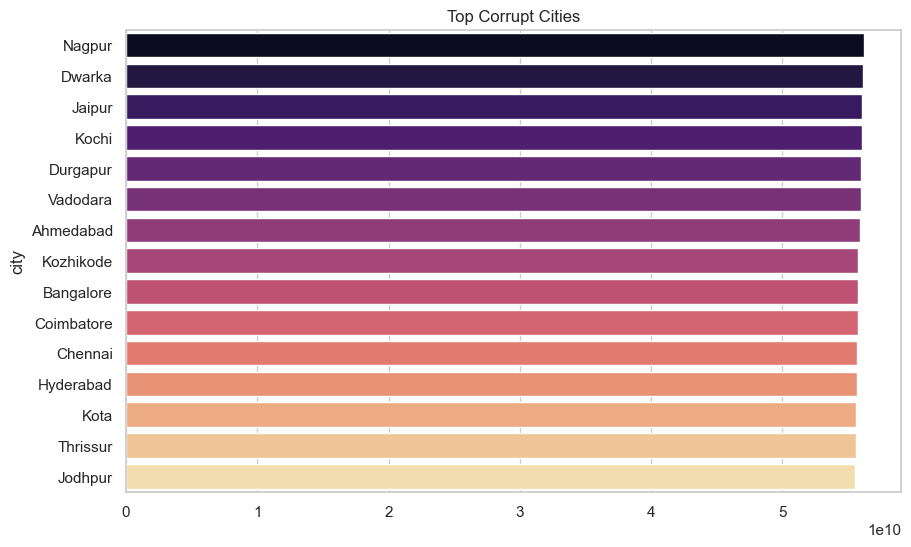

In [47]:
city_corr = df.groupby("city")["corruption_amount_rs"].sum().sort_values(ascending=False).head(15)

plt.figure()

sns.barplot(
x=city_corr.values,
y=city_corr.index,
palette="magma"
)

plt.title("Top Corrupt Cities")

plt.show()

#### Actual vs Allocated Budget

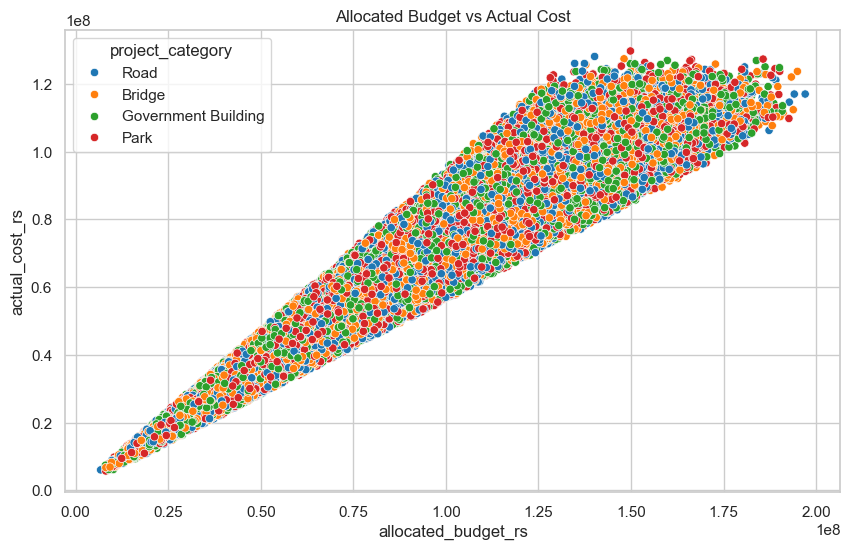

In [49]:
plt.figure()

sns.scatterplot(
data=df,
x="allocated_budget_rs",
y="actual_cost_rs",
hue="project_category",
palette="tab10"
)

plt.title("Allocated Budget vs Actual Cost")

plt.show()

#### Corruption by State + Category 

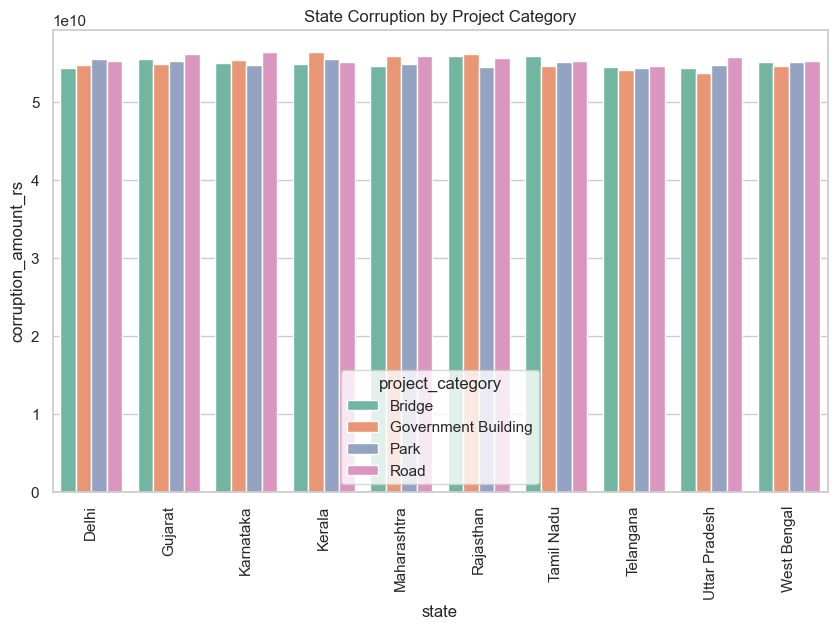

In [50]:
state_cat = df.groupby(["state","project_category"])["corruption_amount_rs"].sum().reset_index()

plt.figure()

sns.barplot(
data=state_cat,
x="state",
y="corruption_amount_rs",
hue="project_category",
palette="Set2"
)

plt.xticks(rotation=90)

plt.title("State Corruption by Project Category")

plt.show()

#### City Corruption + Category 

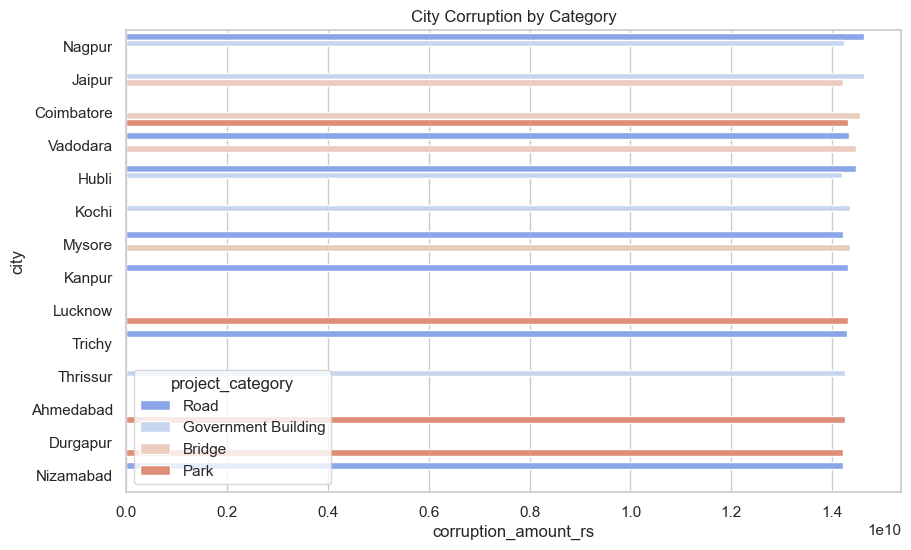

In [51]:
city_cat = df.groupby(["city","project_category"])["corruption_amount_rs"].sum().reset_index()

top_city = city_cat.sort_values("corruption_amount_rs",ascending=False).head(20)

plt.figure()

sns.barplot(
data=top_city,
x="corruption_amount_rs",
y="city",
hue="project_category",
palette="coolwarm"
)

plt.title("City Corruption by Category")

plt.show()

#### Budget vs Corruption by State 

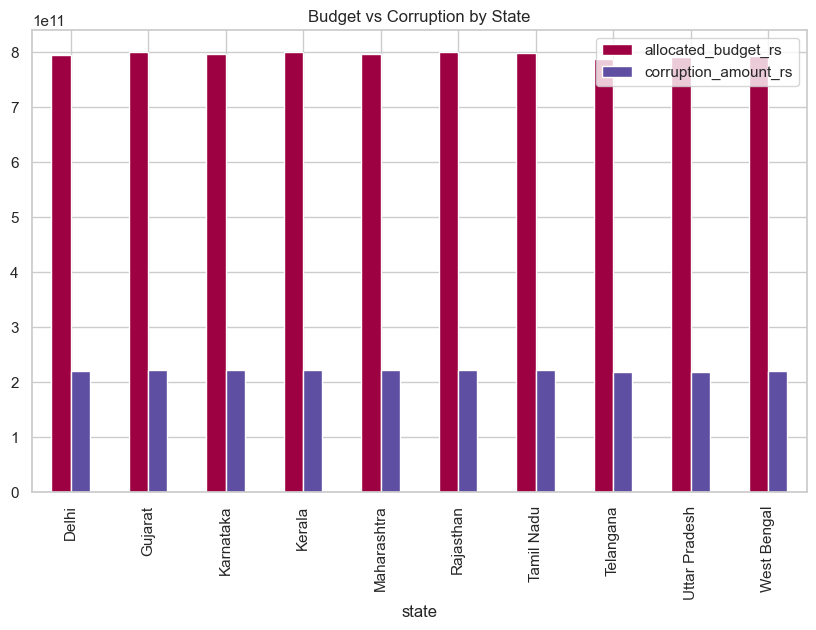

In [52]:
state_budget = df.groupby("state")[["allocated_budget_rs","corruption_amount_rs"]].sum()

state_budget.plot(kind="bar",colormap="Spectral")

plt.title("Budget vs Corruption by State")

plt.show()

#### Budget vs Corruption by City 

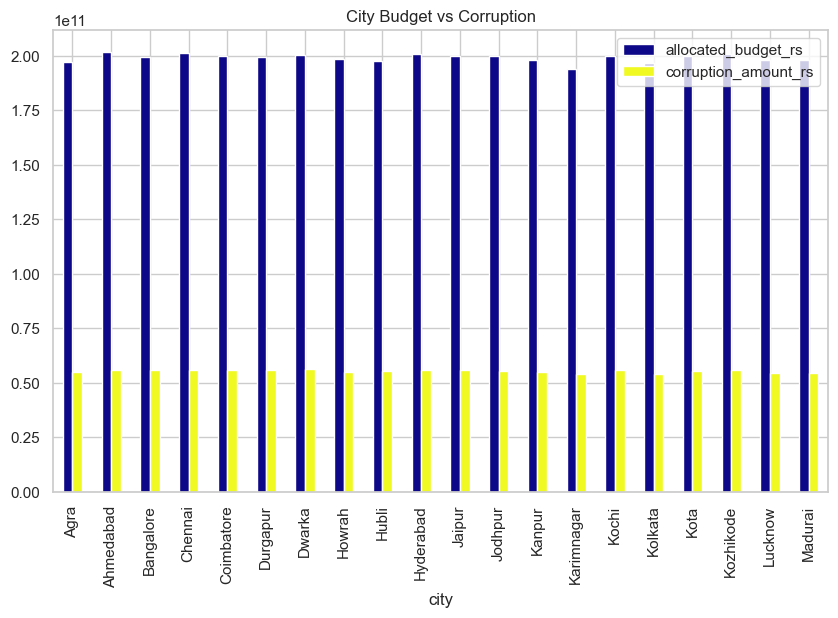

In [53]:
city_budget = df.groupby("city")[["allocated_budget_rs","corruption_amount_rs"]].sum().head(20)

city_budget.plot(kind="bar",colormap="plasma")

plt.title("City Budget vs Corruption")

plt.show()

#### Corruption Trend by Year 

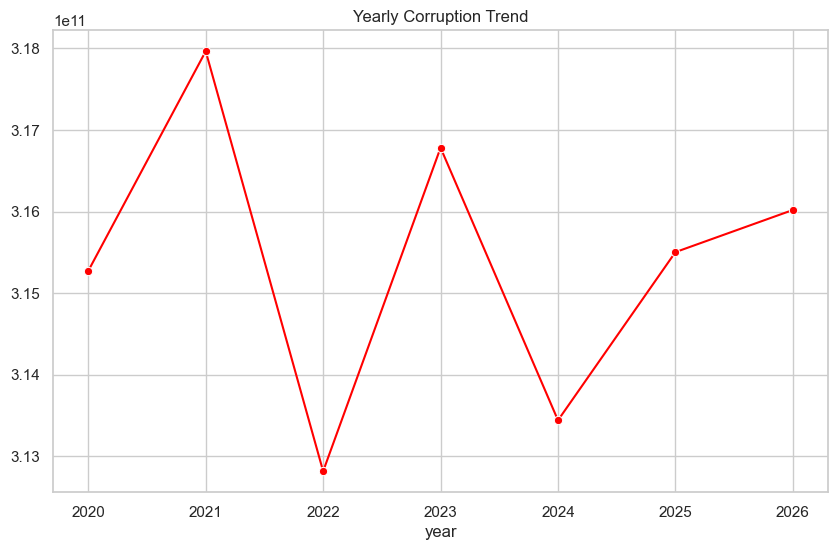

In [54]:
year_corr = df.groupby("year")["corruption_amount_rs"].sum()

plt.figure()

sns.lineplot(
x=year_corr.index,
y=year_corr.values,
marker="o",
color="red"
)

plt.title("Yearly Corruption Trend")

plt.show()

#### Corruption by Population Impact 

/var/folders/t9/h05j4qf9681bhyc90g6gvsw80000gn/T/ipykernel_20210/32165842.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


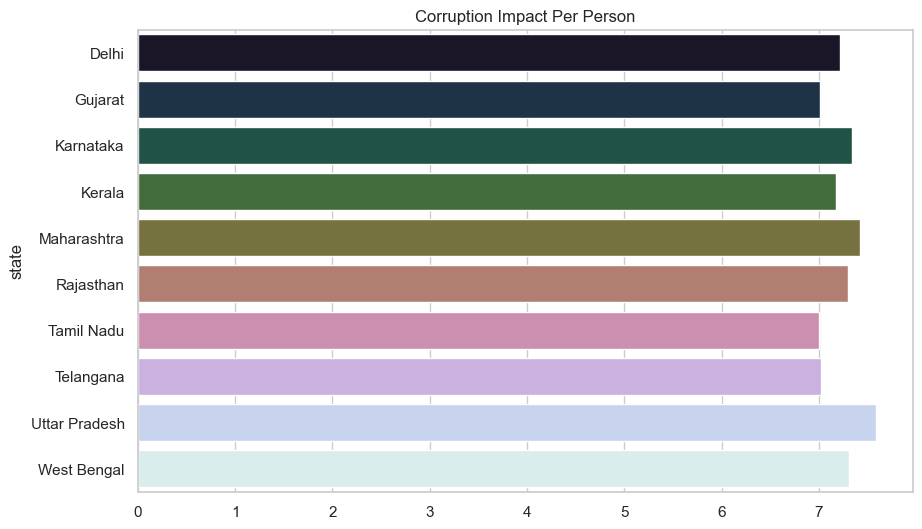

In [55]:
df["corruption_per_person"] = df["corruption_amount_rs"] / df["population"]

state_pop = df.groupby("state")["corruption_per_person"].mean()

plt.figure()

sns.barplot(
x=state_pop.values,
y=state_pop.index,
palette="cubehelix"
)

plt.title("Corruption Impact Per Person")

plt.show()

#### Encode Categorical Features

In [56]:
city_encoder = LabelEncoder()
state_encoder = LabelEncoder()
category_encoder = LabelEncoder()

df["city"] = city_encoder.fit_transform(df["city"])
df["state"] = state_encoder.fit_transform(df["state"])
df["project_category"] = category_encoder.fit_transform(df["project_category"])

##### save encoder

In [57]:
with open("city_encoder.pkl","wb") as f:
    pickle.dump(city_encoder,f)

with open("state_encoder.pkl","wb") as f:
    pickle.dump(state_encoder,f)

with open("category_encoder.pkl","wb") as f:
    pickle.dump(category_encoder,f)

#### Feature Selection

In [58]:
features = [
"state",
"city",
"year",
"project_category",
"population",
"traffic_density",
"material_cost_rs",
"labour_cost_rs",
"equipment_cost_rs",
"expected_cost_rs",
"allocated_budget_rs"
]

In [59]:
target = "corruption_amount_rs"

#### Prepare Training Data

In [60]:
X = df[features]

y = df[target]

#### Scale Features

In [61]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##### save scaler:

In [62]:
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

##### save feature:

In [63]:
with open("features.pkl","wb") as f:
    pickle.dump(features,f)

#### Train Test Split

In [64]:
X_train,X_test,y_train,y_test = train_test_split(
X_scaled,
y,
test_size=0.2,
random_state=42
)

#### Build ANN Model

In [65]:
model = Sequential()

model.add(Dense(128,activation="relu",input_shape=(X_train.shape[1],)))

model.add(Dense(64,activation="relu"))

model.add(Dense(32,activation="relu"))

model.add(Dense(1))

/opt/anaconda3/envs/ai_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### compile

In [66]:
model.compile(
optimizer="adam",
loss="mse",
metrics=["mae"]
)

#### Train ANN

In [67]:
history = model.fit(
X_train,
y_train,
epochs=40,
batch_size=64,
validation_split=0.2
)

Epoch 1/40
896/896 ━━━━━━━━━━━━━━━━━━━━ 2s 868us/step - loss: 761130817421312.0000 - mae: 23952918.0000 - val_loss: 596574245748736.0000 - val_mae: 21089248.0000
Epoch 2/40
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - loss: 303122182307840.0000 - mae: 14216018.0000 - val_loss: 152727174774784.0000 - val_mae: 9977259.0000
Epoch 3/40
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step - loss: 128818928943104.0000 - mae: 9120430.0000 - val_loss: 106357944483840.0000 - val_mae: 8328876.0000
Epoch 4/40
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 739us/step - loss: 94161881530368.0000 - mae: 7852588.5000 - val_loss: 81618622480384.0000 - val_mae: 7332541.5000
Epoch 5/40
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 739us/step - loss: 73558587867136.0000 - mae: 6966710.5000 - val_loss: 64781927055360.0000 - val_mae: 6530689.0000
Epoch 6/40
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 740us/step - loss: 58033015095296.0000 - mae: 6183331.5000 - val_loss: 50645214167040.0000 - val_mae: 5766425.5000
Epoch 7/40
896/896 ━━━━━━━━━━━━━━━━━━━━ 1s 

#### Training Curve

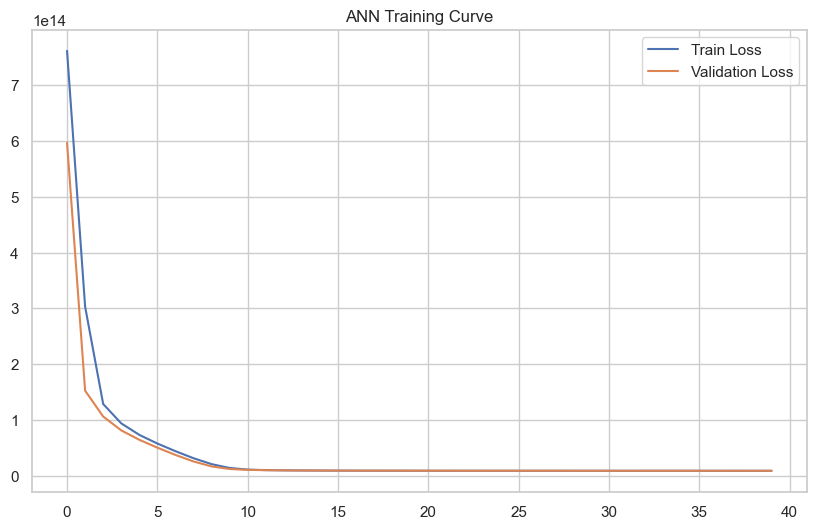

In [68]:
plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")

plt.legend()

plt.title("ANN Training Curve")

plt.show()

#### Evaluate Model

In [69]:
preds = model.predict(X_test)

print("MAE:",mean_absolute_error(y_test,preds))

print("R2:",r2_score(y_test,preds))

560/560 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step
MAE: 2467258.0
R2: 0.9529314041137695


##### save model

In [71]:
model.save("corruption_ann_model.h5")